# mBART Model Evaluation - Sinhala Spelling Correction

**Model:** Fine-tuned mBART-large-50 for Sinhala Spelling Correction

**Evaluation Metrics:**
- BLEU Score (1-4 grams)
- Character Error Rate (CER)
- Word Error Rate (WER)
- Exact Match Accuracy

**Text Normalization:**
- SinhalaCodeMixedNormalizer applied to all predictions and references

**Visualizations:**
- Metric comparison charts
- Error distribution analysis
- Confusion matrix for common errors
- Sample predictions table

## Step 1: Install Dependencies

In [21]:
!pip install -q datasets huggingface-hub transformers sentencepiece
!pip install -q torch torchvision torchaudio
!pip install -q evaluate sacrebleu jiwer
!pip install -q matplotlib seaborn pandas numpy scikit-learn
!pip install -q plotly kaleido
print("✓ All dependencies installed successfully")

✓ All dependencies installed successfully


## Step 2: Import Libraries

In [22]:
import os
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
import evaluate
from jiwer import wer, cer
from collections import Counter, defaultdict
from tqdm.auto import tqdm
import warnings
warnings.filterwarnings('ignore')

# Setup visualization style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✓ Libraries imported successfully")
print(f"PyTorch version: {torch.__version__}")
print(f"Device: {'cuda' if torch.cuda.is_available() else 'cpu'}")

✓ Libraries imported successfully
PyTorch version: 2.9.0+cu126
Device: cuda


In [23]:
import unicodedata
import re

class SinhalaCodeMixedNormalizer:
    """Normalizer for Sinhala code-mixed text"""
    def __call__(self, text: str) -> str:
        # Unicode normalize
        text = unicodedata.normalize("NFC", text)

        # Lowercase
        text = text.lower()

        # Keep: Sinhala, English letters, numbers, spaces
        text = re.sub(r"[^\u0D80-\u0DFF\u200da-z0-9\s]", " ", text)

        # Normalize whitespace
        text = re.sub(r"\s+", " ", text).strip()

        return text

# Initialize normalizer
normalizer = SinhalaCodeMixedNormalizer()
print("✓ Sinhala Code-Mixed Normalizer initialized")

✓ Sinhala Code-Mixed Normalizer initialized


## Step 3: Configuration

In [24]:
# Configuration
CONFIG = {
    "model_path": "SPEAK-ASR/mBART-large-50-si",  # Your trained model on Hugging Face Hub
    "dataset_id": "SPEAK-ASR/sinhala-spelling-correction",
    "source_lang": "si_LK",
    "target_lang": "si_LK",
    "max_length": 128,
    "batch_size": 16,
    "num_beams": 4,
    "sample_size": 100,  # Number of samples to display
}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"\n{'='*70}")
print("MODEL EVALUATION CONFIGURATION")
print(f"{'='*70}\n")
for key, value in CONFIG.items():
    print(f"{key:20s}: {value}")
print(f"\nDevice: {device}\n")


MODEL EVALUATION CONFIGURATION

model_path          : SPEAK-ASR/mBART-large-50-si
dataset_id          : SPEAK-ASR/sinhala-spelling-correction
source_lang         : si_LK
target_lang         : si_LK
max_length          : 128
batch_size          : 16
num_beams           : 4
sample_size         : 100

Device: cuda



## Step 4: Load Model and Tokenizer

In [25]:
print("Loading model and tokenizer...")

# Load tokenizer with explicit empty extra_special_tokens to potentially override any malformed config
# The error indicates that special_tokens (which is extra_special_tokens) is a list instead of a dict.
# By passing extra_special_tokens={}, we ensure it's a dict.
tokenizer = AutoTokenizer.from_pretrained(CONFIG["model_path"], extra_special_tokens={})

# Set source and target languages after loading
tokenizer.src_lang = CONFIG["source_lang"]
tokenizer.tgt_lang = CONFIG["target_lang"]

# Load model
model = AutoModelForSeq2SeqLM.from_pretrained(CONFIG["model_path"])
model = model.to(device)
model.eval()

print(f"✓ Model loaded successfully")
print(f"✓ Tokenizer language: src={tokenizer.src_lang}, tgt={tokenizer.tgt_lang}")
print(f"✓ Model parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"✓ Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

Loading model and tokenizer...


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/992 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.44G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/516 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/269 [00:00<?, ?B/s]

✓ Model loaded successfully
✓ Tokenizer language: src=si_LK, tgt=si_LK
✓ Model parameters: 610,879,488
✓ Trainable parameters: 610,879,488


## Step 5: Load Test Dataset

In [26]:
print("Loading test dataset...")

# Load dataset
dataset = load_dataset(CONFIG["dataset_id"])

# Use test split or create one from train
if "test" in dataset:
    test_dataset = dataset["test"]
elif "validation" in dataset:
    test_dataset = dataset["validation"]
else:
    # Split train data
    split_dataset = dataset["train"].train_test_split(test_size=0.3, seed=42)
    test_dataset = split_dataset["test"]

print(f"✓ Test dataset loaded: {len(test_dataset)} samples")
print(f"\nDataset columns: {test_dataset.column_names}")
print(f"\nSample entry:")
print(test_dataset[0])

Loading test dataset...
✓ Test dataset loaded: 9428 samples

Dataset columns: ['dyslexic_sentence', 'clean_sentence']

Sample entry:
{'dyslexic_sentence': 'පොත් පොතක කතා ලියලා තියෙනවා', 'clean_sentence': 'පොත් පොතක කතා ලියලා තියෙනවා'}


## Step 6: Define Evaluation Metrics

In [27]:
# Load evaluation metrics
bleu_metric = evaluate.load("sacrebleu")

def calculate_metrics(predictions, references):
    """
    Calculate comprehensive evaluation metrics with text normalization
    """
    # Apply normalization to predictions and references
    normalized_predictions = [normalizer(pred) for pred in predictions]
    normalized_references = [normalizer(ref) for ref in references]

    metrics = {}

    # BLEU Score (on normalized text)
    bleu_results = bleu_metric.compute(predictions=normalized_predictions, references=[[ref] for ref in normalized_references])
    metrics['bleu'] = bleu_results['score']

    # Character Error Rate (CER) - on normalized text
    cer_scores = [cer(ref, pred) for ref, pred in zip(normalized_references, normalized_predictions)]
    metrics['cer'] = np.mean(cer_scores) * 100

    # Word Error Rate (WER) - on normalized text
    wer_scores = [wer(ref, pred) for ref, pred in zip(normalized_references, normalized_predictions)]
    metrics['wer'] = np.mean(wer_scores) * 100

    # Exact Match Accuracy - on normalized text
    exact_matches = sum(1 for pred, ref in zip(normalized_predictions, normalized_references) if pred.strip() == ref.strip())
    metrics['exact_match'] = (exact_matches / len(normalized_predictions)) * 100

    return metrics, cer_scores, wer_scores

print("✓ Evaluation metrics defined with text normalization")

✓ Evaluation metrics defined with text normalization


## Step 7: Generate Predictions

In [28]:
def generate_predictions(dataset, model, tokenizer, batch_size=16):
    """
    Generate predictions for the entire dataset
    """
    predictions = []
    references = []
    inputs_text = []

    model.eval()

    with torch.no_grad():
        for i in tqdm(range(0, len(dataset), batch_size), desc="Generating predictions"):
            batch = dataset[i:i+batch_size]

            # Get input and target text (adjust column names as needed)
            if "dyslexic_sentence" in batch and "clean_sentence" in batch:
                batch_inputs = batch["dyslexic_sentence"]
                batch_targets = batch["clean_sentence"]
            else:
                raise ValueError(f"Dataset columns not recognized. Available columns: {batch.keys()}")

            # Tokenize inputs
            encoded = tokenizer(
                batch_inputs,
                max_length=CONFIG["max_length"],
                padding=True,
                truncation=True,
                return_tensors="pt"
            ).to(device)

            # Generate predictions
            # Get forced_bos_token_id - handle different transformers versions
            if hasattr(tokenizer, 'lang_code_to_id'):
                forced_bos_id = tokenizer.lang_code_to_id[CONFIG["target_lang"]]
            else:
                # Fallback: convert language token directly to ID
                forced_bos_id = tokenizer.convert_tokens_to_ids(CONFIG["target_lang"])

            generated_tokens = model.generate(
                **encoded,
                max_length=CONFIG["max_length"],
                num_beams=CONFIG["num_beams"],
                early_stopping=True,
                forced_bos_token_id=forced_bos_id
            )

            # Decode predictions
            batch_predictions = tokenizer.batch_decode(generated_tokens, skip_special_tokens=True)

            predictions.extend(batch_predictions)
            references.extend(batch_targets)
            inputs_text.extend(batch_inputs)

    return inputs_text, predictions, references

print("Generating predictions for test dataset...")
inputs_text, predictions, references = generate_predictions(
    test_dataset,
    model,
    tokenizer,
    batch_size=CONFIG["batch_size"]
)

print(f"\n✓ Generated {len(predictions)} predictions")
print(f"\nSample predictions:")
for i in range(min(3, len(predictions))):
    print(f"\n{i+1}.")
    print(f"   Input:      {inputs_text[i]}")
    print(f"   Prediction: {predictions[i]}")
    print(f"   Reference:  {references[i]}")

Generating predictions for test dataset...


Generating predictions:   0%|          | 0/590 [00:00<?, ?it/s]


✓ Generated 9428 predictions

Sample predictions:

1.
   Input:      පොත් පොතක කතා ලියලා තියෙනවා
   Prediction: පොත් පොතක කතා ලියලා තියෙනවා.
   Reference:  පොත් පොතක කතා ලියලා තියෙනවා

2.
   Input:      මට බෙඩිං නෑ
   Prediction: මට බෙඩිං නෑ.
   Reference:  මට බඩගිනි නෑ

3.
   Input:      විදේශ සංචිතය පසුගිය මාර්ථු
   Prediction: විදේශ සංචිතය පසුගිය සතිය
   Reference:  විදේශ සංචිතය පසුගිය මාර්තු


## Step 8: Calculate Metrics

In [29]:
print("Calculating evaluation metrics...\n")

metrics, cer_scores, wer_scores = calculate_metrics(predictions, references)

print(f"{'='*70}")
print("EVALUATION RESULTS (Normalized Text)")
print(f"{'='*70}\n")

print(f"BLEU Score:              {metrics['bleu']:.2f}")
print(f"Character Error Rate:    {metrics['cer']:.2f}%")
print(f"Word Error Rate:         {metrics['wer']:.2f}%")
print(f"Exact Match Accuracy:    {metrics['exact_match']:.2f}%")

Calculating evaluation metrics...

EVALUATION RESULTS (Normalized Text)

BLEU Score:              47.85
Character Error Rate:    20.06%
Word Error Rate:         32.60%
Exact Match Accuracy:    46.74%


## Step 9: Visualization - Metrics Overview

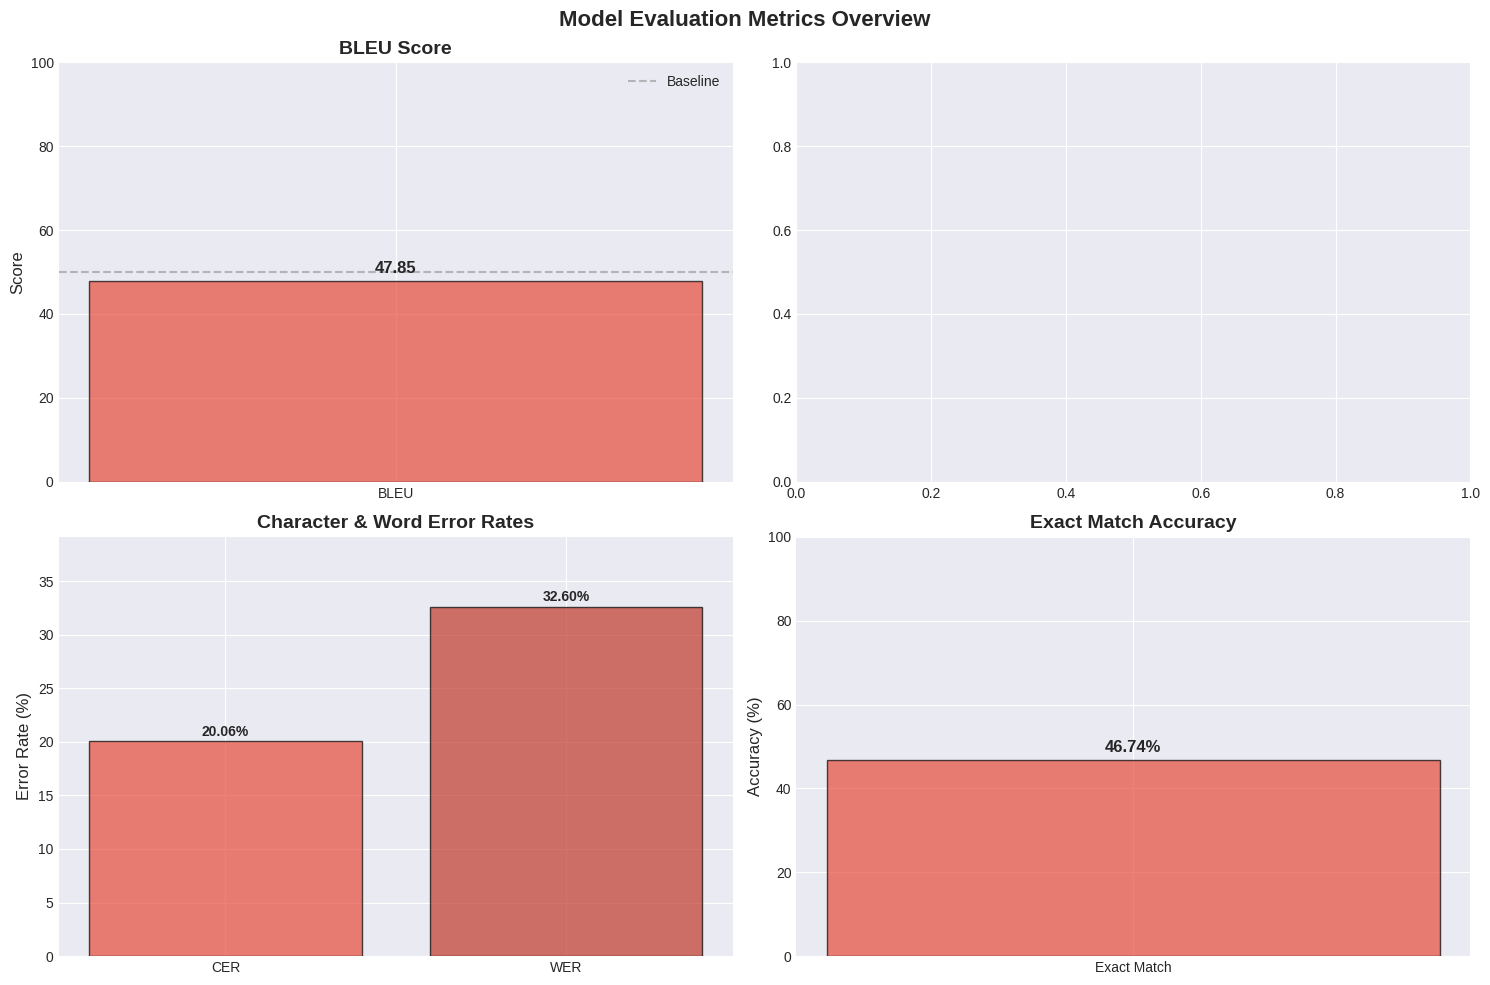

✓ Metrics overview visualization saved as 'evaluation_metrics_overview.png'


In [30]:
# Create metrics bar chart
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Model Evaluation Metrics Overview', fontsize=16, fontweight='bold')

# BLEU Score
ax1 = axes[0, 0]
colors = ['#2ecc71' if metrics['bleu'] > 50 else '#e74c3c']
ax1.bar(['BLEU'], [metrics['bleu']], color=colors, alpha=0.7, edgecolor='black')
ax1.set_ylabel('Score', fontsize=12)
ax1.set_title('BLEU Score', fontsize=14, fontweight='bold')
ax1.set_ylim(0, 100)
ax1.axhline(y=50, color='gray', linestyle='--', alpha=0.5, label='Baseline')
ax1.text(0, metrics['bleu'] + 2, f"{metrics['bleu']:.2f}", ha='center', fontsize=12, fontweight='bold')
ax1.legend()

# Error Rates
ax3 = axes[1, 0]
error_data = [metrics['cer'], metrics['wer']]
error_labels = ['CER', 'WER']
bars = ax3.bar(error_labels, error_data, color=['#e74c3c', '#c0392b'], alpha=0.7, edgecolor='black')
ax3.set_ylabel('Error Rate (%)', fontsize=12)
ax3.set_title('Character & Word Error Rates', fontsize=14, fontweight='bold')
ax3.set_ylim(0, max(error_data) * 1.2)
for bar, value in zip(bars, error_data):
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height + 0.5, f'{value:.2f}%', ha='center', fontsize=10, fontweight='bold')

# Exact Match Accuracy
ax4 = axes[1, 1]
colors = ['#2ecc71' if metrics['exact_match'] > 70 else '#f39c12' if metrics['exact_match'] > 50 else '#e74c3c']
ax4.bar(['Exact Match'], [metrics['exact_match']], color=colors, alpha=0.7, edgecolor='black')
ax4.set_ylabel('Accuracy (%)', fontsize=12)
ax4.set_title('Exact Match Accuracy', fontsize=14, fontweight='bold')
ax4.set_ylim(0, 100)
ax4.text(0, metrics['exact_match'] + 2, f"{metrics['exact_match']:.2f}%", ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('evaluation_metrics_overview.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Metrics overview visualization saved as 'evaluation_metrics_overview.png'")

## Step 10: Error Distribution Analysis

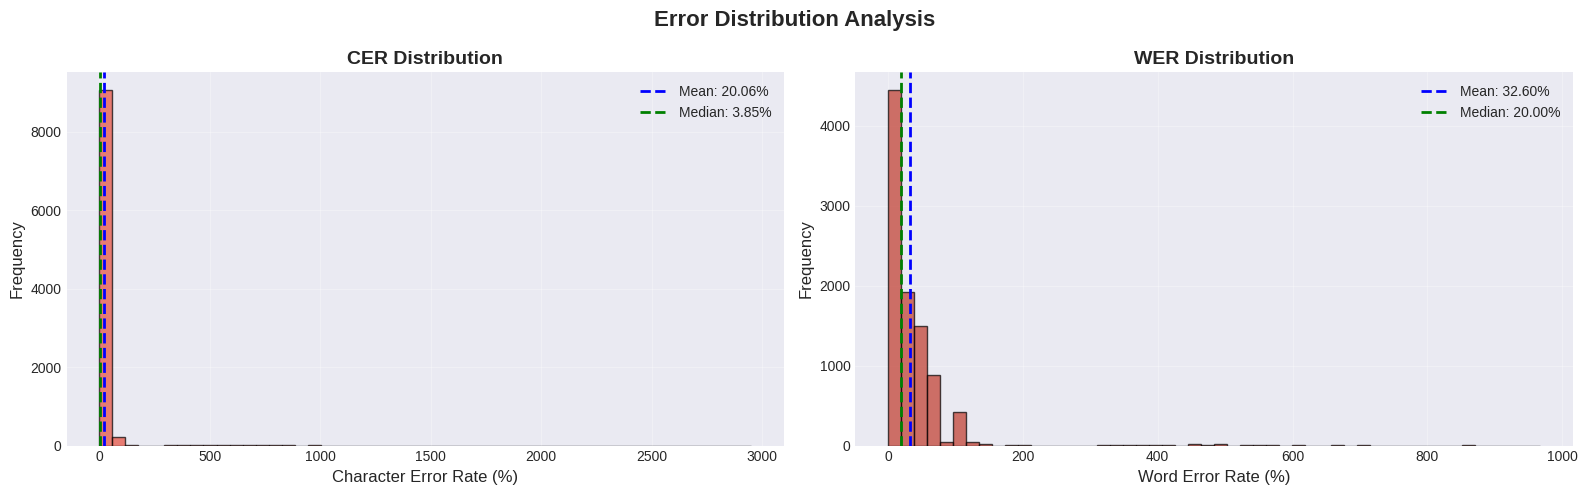


Error Statistics:
CER - Min: 0.00%, Max: 2950.00%, Std: 78.65%
WER - Min: 0.00%, Max: 966.67%, Std: 64.14%

✓ Error distribution saved as 'error_distribution.png'


In [31]:
# Create error distribution plots
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Error Distribution Analysis', fontsize=16, fontweight='bold')

# CER Distribution
ax1 = axes[0]
cer_percentages = [c * 100 for c in cer_scores]
ax1.hist(cer_percentages, bins=50, color='#e74c3c', alpha=0.7, edgecolor='black')
ax1.axvline(metrics['cer'], color='blue', linestyle='--', linewidth=2, label=f'Mean: {metrics["cer"]:.2f}%')
ax1.axvline(np.median(cer_percentages), color='green', linestyle='--', linewidth=2, label=f'Median: {np.median(cer_percentages):.2f}%')
ax1.set_xlabel('Character Error Rate (%)', fontsize=12)
ax1.set_ylabel('Frequency', fontsize=12)
ax1.set_title('CER Distribution', fontsize=14, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# WER Distribution
ax2 = axes[1]
wer_percentages = [w * 100 for w in wer_scores]
ax2.hist(wer_percentages, bins=50, color='#c0392b', alpha=0.7, edgecolor='black')
ax2.axvline(metrics['wer'], color='blue', linestyle='--', linewidth=2, label=f'Mean: {metrics["wer"]:.2f}%')
ax2.axvline(np.median(wer_percentages), color='green', linestyle='--', linewidth=2, label=f'Median: {np.median(wer_percentages):.2f}%')
ax2.set_xlabel('Word Error Rate (%)', fontsize=12)
ax2.set_ylabel('Frequency', fontsize=12)
ax2.set_title('WER Distribution', fontsize=14, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('error_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nError Statistics:")
print(f"CER - Min: {min(cer_percentages):.2f}%, Max: {max(cer_percentages):.2f}%, Std: {np.std(cer_percentages):.2f}%")
print(f"WER - Min: {min(wer_percentages):.2f}%, Max: {max(wer_percentages):.2f}%, Std: {np.std(wer_percentages):.2f}%")
print("\n✓ Error distribution saved as 'error_distribution.png'")

## Step 11: Length Analysis

## Step 12: Interactive Plotly Visualizations

In [32]:
# Create interactive plotly dashboard
fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=('Metrics Radar Chart', 'Error Rates Comparison',
                    'CER vs WER Scatter', 'Performance Summary'),
    specs=[[{'type': 'scatterpolar'}, {'type': 'bar'}],
           [{'type': 'scatter'}, {'type': 'indicator'}]]
)

# Radar chart
categories = ['BLEU','Exact Match']
values = [
    metrics['bleu'],
    metrics['exact_match']
]

fig.add_trace(go.Scatterpolar(
    r=values + [values[0]],
    theta=categories + [categories[0]],
    fill='toself',
    name='Metrics',
    line_color='#3498db'
), row=1, col=1)

# Error rates bar chart
fig.add_trace(go.Bar(
    x=['CER', 'WER'],
    y=[metrics['cer'], metrics['wer']],
    marker_color=['#e74c3c', '#c0392b'],
    text=[f"{metrics['cer']:.2f}%", f"{metrics['wer']:.2f}%"],
    textposition='outside'
), row=1, col=2)

# CER vs WER scatter
fig.add_trace(go.Scatter(
    x=[c * 100 for c in cer_scores],
    y=[w * 100 for w in wer_scores],
    mode='markers',
    marker=dict(size=5, color='#9b59b6', opacity=0.6),
    name='Samples'
), row=2, col=1)

# Performance indicator
overall_score = (metrics['bleu'] + metrics['exact_match']) / 2
fig.add_trace(go.Indicator(
    mode="gauge+number+delta",
    value=overall_score,
    title={'text': "Overall Score"},
    delta={'reference': 75},
    gauge={
        'axis': {'range': [None, 100]},
        'bar': {'color': "darkblue"},
        'steps': [
            {'range': [0, 50], 'color': "lightgray"},
            {'range': [50, 75], 'color': "gray"}],
        'threshold': {
            'line': {'color': "red", 'width': 4},
            'thickness': 0.75,
            'value': 90}
    }
), row=2, col=2)

# Update layout
fig.update_layout(
    title_text="Model Evaluation Dashboard",
    height=800,
    showlegend=False
)

fig.update_xaxes(title_text="CER (%)", row=2, col=1)
fig.update_yaxes(title_text="WER (%)", row=2, col=1)

fig.show()
fig.write_html('interactive_dashboard.html')
print("✓ Interactive dashboard saved as 'interactive_dashboard.html'")

✓ Interactive dashboard saved as 'interactive_dashboard.html'


## Step 13: Sample Predictions Table

In [33]:
# Create detailed predictions DataFrame
predictions_df = pd.DataFrame({
    'Input': inputs_text,
    'Prediction': predictions,
    'Reference': references,
    'Exact Match': [pred.strip() == ref.strip() for pred, ref in zip(predictions, references)],
    'CER (%)': [c * 100 for c in cer_scores],
    'WER (%)': [w * 100 for w in wer_scores]
})

# Display sample predictions
print(f"\n{'='*120}")
print("SAMPLE PREDICTIONS")
print(f"{'='*120}\n")

sample_size = min(CONFIG['sample_size'], len(predictions_df))
display_df = predictions_df.head(sample_size)

print(display_df.to_string(index=True, max_colwidth=50))

# Save full predictions to CSV
predictions_df.to_csv('full_predictions.csv', index=False, encoding='utf-8')
print(f"\n✓ Full predictions saved to 'full_predictions.csv' ({len(predictions_df)} samples)")


SAMPLE PREDICTIONS

                                        Input                                   Prediction                                  Reference  Exact Match    CER (%)     WER (%)
0                 පොත් පොතක කතා ලියලා තියෙනවා                 පොත් පොතක කතා ලියලා තියෙනවා.                පොත් පොතක කතා ලියලා තියෙනවා        False   0.000000    0.000000
1                                 මට බෙඩිං නෑ                                 මට බෙඩිං නෑ.                               මට බඩගිනි නෑ        False  33.333333   33.333333
2                  විදේශ සංචිතය පසුගිය මාර්ථු                     විදේශ සංචිතය පසුගිය සතිය                 විදේශ සංචිතය පසුගිය මාර්තු        False  23.076923   25.000000
3                         අම්මා කුස්සියෙ උයනව                         අම්මා කුස්සියේ උයනවා                       අම්මා කුස්සියේ උයනවා         True   0.000000    0.000000
4                            සොයිර ගහ ලස්සනයි                               සොර ගහ ලස්සනයි                           සොයිර ගහ ලස්

## Step 14: Best and Worst Predictions


TOP 10 BEST PREDICTIONS (Lowest CER)

                                   Input                          Prediction                           Reference  Exact Match  CER (%)  WER (%)
6103                 එයා ගාව සල්ලි තිබ්බ               එයා ගාව සල්ලි තිබ්බා.                එයා ගාව සල්ලි තිබ්බා        False      0.0      0.0
3012             අපේ ගමෙ පන්සලක් තියෙනවා            අපේ ගමේ පන්සලක් තියෙනවා.             අපේ ගමේ පන්සලක් තියෙනවා        False      0.0      0.0
3011             පොළේ සභාපතිවරයා වන වජිර             පොළේ සභාපතිවරයා වන වජිර             පොළේ සභාපතිවරයා වන වජිර         True      0.0      0.0
3009  කරන fundamental analysis එකයි දෙකම  කරන fundamental analysis එකයි දෙකම  කරන fundamental analysis එකයි දෙකම         True      0.0      0.0
3008                           මම කතාකරල                         මම කතා කරලා                         මම කතා කරලා         True      0.0      0.0
3006                        එයා හිනාවෙනව                      එයා හිනාවෙනවා.                     

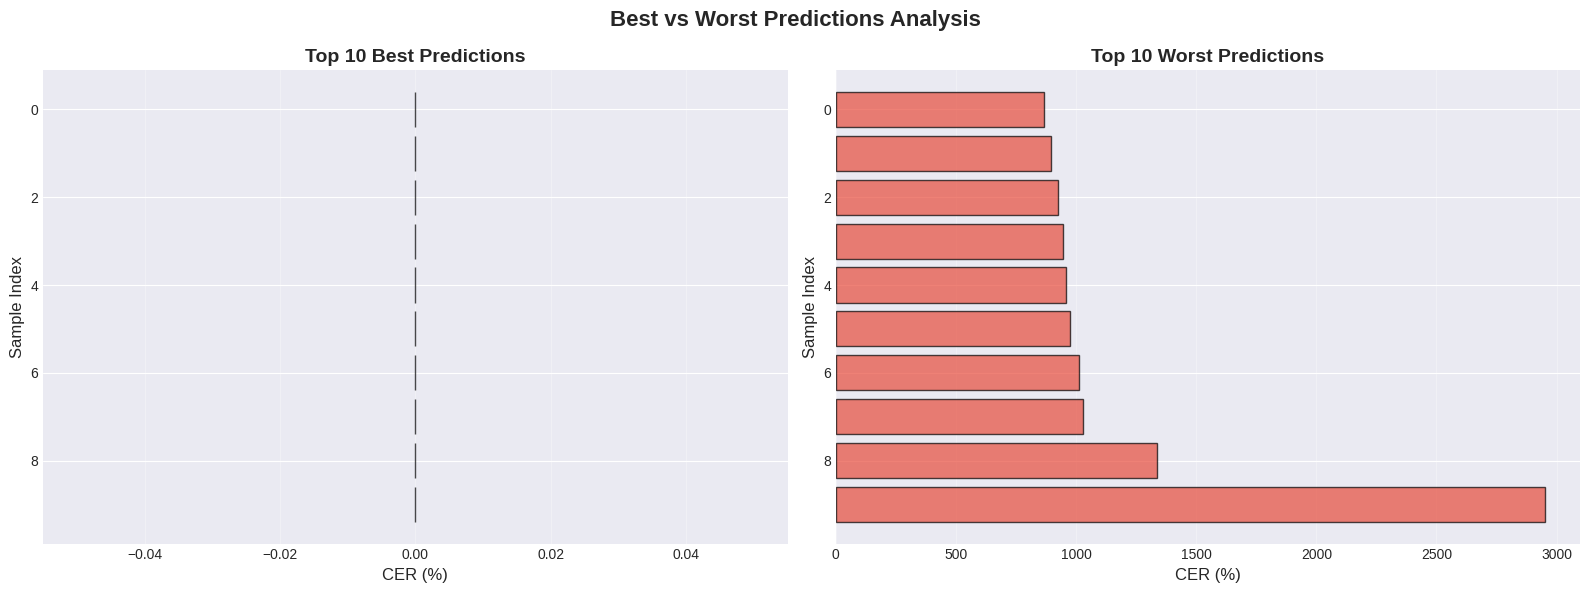


✓ Best/worst predictions saved as 'best_worst_predictions.png'


In [34]:
# Sort by CER to find best and worst predictions
predictions_df_sorted = predictions_df.sort_values('CER (%)')

print(f"\n{'='*120}")
print("TOP 10 BEST PREDICTIONS (Lowest CER)")
print(f"{'='*120}\n")
print(predictions_df_sorted.head(10).to_string(index=True, max_colwidth=50))

print(f"\n{'='*120}")
print("TOP 10 WORST PREDICTIONS (Highest CER)")
print(f"{'='*120}\n")
print(predictions_df_sorted.tail(10).to_string(index=True, max_colwidth=50))

# Create visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Best vs Worst Predictions Analysis', fontsize=16, fontweight='bold')

# Best predictions
ax1 = axes[0]
best_10 = predictions_df_sorted.head(10)
ax1.barh(range(10), best_10['CER (%)'].values, color='#2ecc71', alpha=0.7, edgecolor='black')
ax1.set_xlabel('CER (%)', fontsize=12)
ax1.set_ylabel('Sample Index', fontsize=12)
ax1.set_title('Top 10 Best Predictions', fontsize=14, fontweight='bold')
ax1.invert_yaxis()
ax1.grid(True, alpha=0.3, axis='x')

# Worst predictions
ax2 = axes[1]
worst_10 = predictions_df_sorted.tail(10)
ax2.barh(range(10), worst_10['CER (%)'].values, color='#e74c3c', alpha=0.7, edgecolor='black')
ax2.set_xlabel('CER (%)', fontsize=12)
ax2.set_ylabel('Sample Index', fontsize=12)
ax2.set_title('Top 10 Worst Predictions', fontsize=14, fontweight='bold')
ax2.invert_yaxis()
ax2.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('best_worst_predictions.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Best/worst predictions saved as 'best_worst_predictions.png'")

## Step 15: Error Category Analysis


PERFORMANCE DISTRIBUTION

Excellent (<5%)     : 4994 samples (52.97%)
Very Poor (>30%)    : 1463 samples (15.52%)
Fair (10-20%)       : 1102 samples (11.69%)
Good (5-10%)        : 1021 samples (10.83%)
Poor (20-30%)       :  848 samples ( 8.99%)


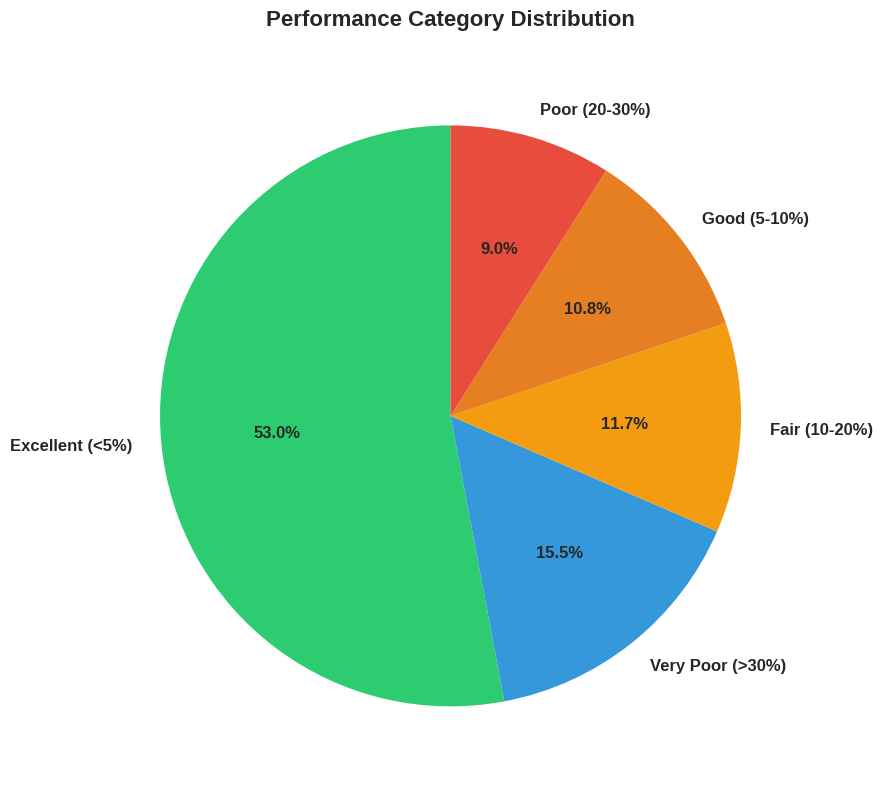


✓ Performance distribution saved as 'performance_distribution.png'


In [35]:
# Categorize errors by performance level
def categorize_performance(cer):
    cer_pct = cer * 100
    if cer_pct < 5:
        return 'Excellent (<5%)'
    elif cer_pct < 10:
        return 'Good (5-10%)'
    elif cer_pct < 20:
        return 'Fair (10-20%)'
    elif cer_pct < 30:
        return 'Poor (20-30%)'
    else:
        return 'Very Poor (>30%)'

predictions_df['Performance Category'] = [categorize_performance(c) for c in cer_scores]

# Count samples in each category
category_counts = predictions_df['Performance Category'].value_counts()

print(f"\n{'='*70}")
print("PERFORMANCE DISTRIBUTION")
print(f"{'='*70}\n")
for category, count in category_counts.items():
    percentage = (count / len(predictions_df)) * 100
    print(f"{category:20s}: {count:4d} samples ({percentage:5.2f}%)")

# Create pie chart
fig, ax = plt.subplots(figsize=(10, 8))
colors = ['#2ecc71', '#3498db', '#f39c12', '#e67e22', '#e74c3c']
wedges, texts, autotexts = ax.pie(
    category_counts.values,
    labels=category_counts.index,
    colors=colors[:len(category_counts)],
    autopct='%1.1f%%',
    startangle=90,
    textprops={'fontsize': 12, 'weight': 'bold'}
)
ax.set_title('Performance Category Distribution', fontsize=16, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('performance_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Performance distribution saved as 'performance_distribution.png'")

## Step 15.5: Confusion Matrix Analysis

This confusion matrix categorizes spelling correction outcomes:
- **True Positive (TP)**: Input was misspelled → Model correctly fixed it
- **True Negative (TN)**: Input was already correct → Model kept it correct
- **False Positive (FP)**: Input was already correct → Model incorrectly changed it
- **False Negative (FN)**: Input was misspelled → Model failed to fix it

In [36]:
# Confusion Matrix for Spelling Correction Evaluation
# Categories:
# - Input Status: Was the input already correct (same as reference) or incorrect (different from reference)?
# - Prediction Outcome: Did the model produce the correct output (matches reference) or not?

def classify_prediction(input_text, prediction, reference):
    """
    Classify each prediction into TP, TN, FP, or FN
    Using normalized text for comparison
    """
    norm_input = normalizer(input_text)
    norm_pred = normalizer(prediction)
    norm_ref = normalizer(reference)

    input_was_correct = (norm_input == norm_ref)
    prediction_is_correct = (norm_pred == norm_ref)

    if input_was_correct and prediction_is_correct:
        return 'TN'  # True Negative: Correct input, kept correct
    elif input_was_correct and not prediction_is_correct:
        return 'FP'  # False Positive: Correct input, incorrectly changed
    elif not input_was_correct and prediction_is_correct:
        return 'TP'  # True Positive: Incorrect input, correctly fixed
    else:
        return 'FN'  # False Negative: Incorrect input, not fixed

# Classify all predictions
predictions_df['Classification'] = [
    classify_prediction(inp, pred, ref)
    for inp, pred, ref in zip(inputs_text, predictions, references)
]

# Count classifications
classification_counts = predictions_df['Classification'].value_counts()

# Create confusion matrix array
tp = classification_counts.get('TP', 0)
tn = classification_counts.get('TN', 0)
fp = classification_counts.get('FP', 0)
fn = classification_counts.get('FN', 0)

confusion_matrix = np.array([[tn, fp], [fn, tp]])

print(f"\n{'='*70}")
print("CONFUSION MATRIX ANALYSIS")
print(f"{'='*70}\n")
print(f"Classification Summary:")
print(f"  True Positives  (Misspelled → Fixed):       {tp:4d} ({tp/len(predictions_df)*100:.1f}%)")
print(f"  True Negatives  (Correct → Kept Correct):   {tn:4d} ({tn/len(predictions_df)*100:.1f}%)")
print(f"  False Positives (Correct → Changed):        {fp:4d} ({fp/len(predictions_df)*100:.1f}%)")
print(f"  False Negatives (Misspelled → Not Fixed):   {fn:4d} ({fn/len(predictions_df)*100:.1f}%)")

# Calculate additional metrics
total_misspelled = tp + fn
total_correct_input = tn + fp

if total_misspelled > 0:
    correction_rate = (tp / total_misspelled) * 100
    print(f"\nCorrection Rate (TP/(TP+FN)):  {correction_rate:.2f}%")
else:
    correction_rate = None
    print(f"\nCorrection Rate: N/A (no misspelled inputs)")

if total_correct_input > 0:
    preservation_rate = (tn / total_correct_input) * 100
    print(f"Preservation Rate (TN/(TN+FP)): {preservation_rate:.2f}%")
else:
    preservation_rate = None
    print(f"Preservation Rate: N/A (no correct inputs)")

# Also compute precision, recall, F1 if applicable
if tp + fp > 0:
    precision = tp / (tp + fp)
    print(f"\nPrecision (TP/(TP+FP)): {precision:.4f}")
else:
    precision = None

if tp + fn > 0:
    recall = tp / (tp + fn)
    print(f"Recall (TP/(TP+FN)): {recall:.4f}")
else:
    recall = None

if precision and recall and (precision + recall) > 0:
    f1 = 2 * (precision * recall) / (precision + recall)
    print(f"F1 Score: {f1:.4f}")


CONFUSION MATRIX ANALYSIS

Classification Summary:
  True Positives  (Misspelled → Fixed):       2929 (31.1%)
  True Negatives  (Correct → Kept Correct):   1478 (15.7%)
  False Positives (Correct → Changed):         665 (7.1%)
  False Negatives (Misspelled → Not Fixed):   4356 (46.2%)

Correction Rate (TP/(TP+FN)):  40.21%
Preservation Rate (TN/(TN+FP)): 68.97%

Precision (TP/(TP+FP)): 0.8150
Recall (TP/(TP+FN)): 0.4021
F1 Score: 0.5385


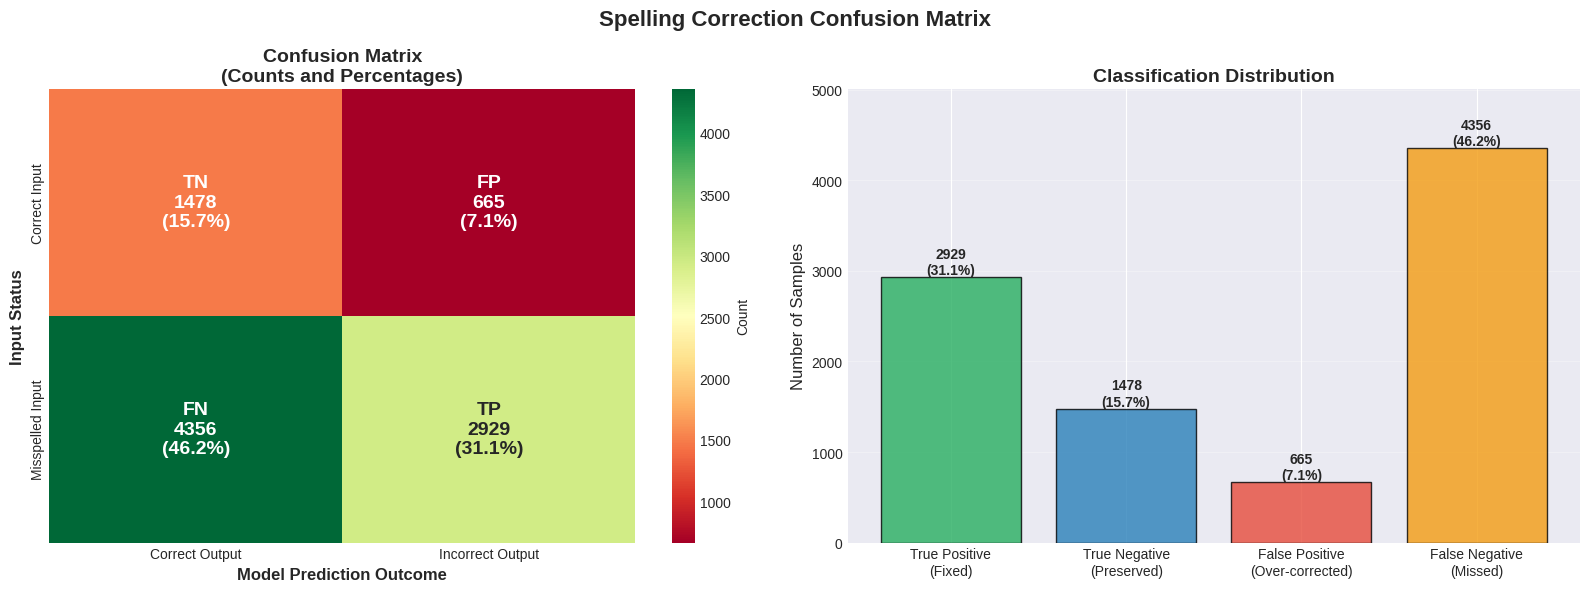


✓ Confusion matrix saved as 'confusion_matrix.png'


In [37]:
# Visualize Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Spelling Correction Confusion Matrix', fontsize=16, fontweight='bold')

# Heatmap of confusion matrix
ax1 = axes[0]
labels = np.array([
    [f'TN\n{tn}\n({tn/len(predictions_df)*100:.1f}%)', f'FP\n{fp}\n({fp/len(predictions_df)*100:.1f}%)'],
    [f'FN\n{fn}\n({fn/len(predictions_df)*100:.1f}%)', f'TP\n{tp}\n({tp/len(predictions_df)*100:.1f}%)']
])

sns.heatmap(confusion_matrix, annot=labels, fmt='', cmap='RdYlGn',
            xticklabels=['Correct Output', 'Incorrect Output'],
            yticklabels=['Correct Input', 'Misspelled Input'],
            cbar_kws={'label': 'Count'},
            ax=ax1, annot_kws={'size': 14, 'weight': 'bold'})
ax1.set_xlabel('Model Prediction Outcome', fontsize=12, fontweight='bold')
ax1.set_ylabel('Input Status', fontsize=12, fontweight='bold')
ax1.set_title('Confusion Matrix\n(Counts and Percentages)', fontsize=14, fontweight='bold')

# Bar chart of classifications
ax2 = axes[1]
categories = ['True Positive\n(Fixed)', 'True Negative\n(Preserved)',
              'False Positive\n(Over-corrected)', 'False Negative\n(Missed)']
counts = [tp, tn, fp, fn]
colors = ['#27ae60', '#2980b9', '#e74c3c', '#f39c12']
bars = ax2.bar(categories, counts, color=colors, alpha=0.8, edgecolor='black')
ax2.set_ylabel('Number of Samples', fontsize=12)
ax2.set_title('Classification Distribution', fontsize=14, fontweight='bold')
ax2.set_ylim(0, max(counts) * 1.15)

for bar, count in zip(bars, counts):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 0.5,
             f'{count}\n({count/len(predictions_df)*100:.1f}%)',
             ha='center', va='bottom', fontsize=10, fontweight='bold')

ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Confusion matrix saved as 'confusion_matrix.png'")

In [38]:
# Show sample predictions for each category
print(f"\n{'='*120}")
print("SAMPLE PREDICTIONS BY CATEGORY")
print(f"{'='*120}")

for category, label in [('TP', 'TRUE POSITIVES (Misspelled → Correctly Fixed)'),
                         ('TN', 'TRUE NEGATIVES (Correct Input → Kept Correct)'),
                         ('FP', 'FALSE POSITIVES (Correct Input → Incorrectly Changed)'),
                         ('FN', 'FALSE NEGATIVES (Misspelled → Not Fixed)')]:
    category_samples = predictions_df[predictions_df['Classification'] == category]

    print(f"\n{'-'*120}")
    print(f"{label}: {len(category_samples)} samples")
    print(f"{'-'*120}")

    if len(category_samples) > 0:
        # Show up to 5 samples
        for idx, (_, row) in enumerate(category_samples.head(5).iterrows()):
            print(f"\n  Sample {idx+1}:")
            print(f"    Input:      {row['Input'][:80]}{'...' if len(str(row['Input'])) > 80 else ''}")
            print(f"    Prediction: {row['Prediction'][:80]}{'...' if len(str(row['Prediction'])) > 80 else ''}")
            print(f"    Reference:  {row['Reference'][:80]}{'...' if len(str(row['Reference'])) > 80 else ''}")
    else:
        print("  No samples in this category.")


SAMPLE PREDICTIONS BY CATEGORY

------------------------------------------------------------------------------------------------------------------------
TRUE POSITIVES (Misspelled → Correctly Fixed): 2929 samples
------------------------------------------------------------------------------------------------------------------------

  Sample 1:
    Input:      අම්මා කුස්සියෙ උයනව
    Prediction: අම්මා කුස්සියේ උයනවා
    Reference:  අම්මා කුස්සියේ උයනවා

  Sample 2:
    Input:      අම්මා මට බත් උයල ඩුන්න
    Prediction: අම්මා මට බත් උයලා දුන්නා
    Reference:  අම්මා මට බත් උයලා දුන්නා

  Sample 3:
    Input:      පූසෙක් ගෙට ආව
    Prediction: පූසෙක් ගෙට ආවා.
    Reference:  පූසෙක් ගෙට ආවා

  Sample 4:
    Input:      එයත් එක්ක කතාකරන්න ඔන
    Prediction: එයත් එක්ක කතාකරන්න ඕන.
    Reference:  එයත් එක්ක කතාකරන්න ඕන

  Sample 5:
    Input:      මට පොතක් ඕන වුනා
    Prediction: මට පොතක් ඕන වුණා.
    Reference:  මට පොතක් ඕන වුණා

------------------------------------------------------------

## Step 16: Generate Final Evaluation Report

In [39]:
# Generate comprehensive evaluation report
report = f"""
{'='*80}
                    MODEL EVALUATION REPORT
{'='*80}

Model: {CONFIG['model_path']}
Dataset: {CONFIG['dataset_id']}
Test Samples: {len(predictions_df)}
Date: {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')}
Text Normalization: SinhalaCodeMixedNormalizer Applied

{'='*80}
                       KEY METRICS
{'='*80}

BLEU Score:                {metrics['bleu']:.2f}
Character Error Rate:      {metrics['cer']:.2f}%
Word Error Rate:           {metrics['wer']:.2f}%
Exact Match Accuracy:      {metrics['exact_match']:.2f}%

{'='*80}
                    STATISTICAL SUMMARY
{'='*80}

CER Statistics:
  Mean:     {metrics['cer']:.2f}%
  Median:   {np.median([c*100 for c in cer_scores]):.2f}%
  Std Dev:  {np.std([c*100 for c in cer_scores]):.2f}%
  Min:      {min([c*100 for c in cer_scores]):.2f}%
  Max:      {max([c*100 for c in cer_scores]):.2f}%

WER Statistics:
  Mean:     {metrics['wer']:.2f}%
  Median:   {np.median([w*100 for w in wer_scores]):.2f}%
  Std Dev:  {np.std([w*100 for w in wer_scores]):.2f}%
  Min:      {min([w*100 for w in wer_scores]):.2f}%
  Max:      {max([w*100 for w in wer_scores]):.2f}%

{'='*80}
                 PERFORMANCE DISTRIBUTION
{'='*80}

"""

for category, count in category_counts.items():
    percentage = (count / len(predictions_df)) * 100
    report += f"{category:20s}: {count:4d} samples ({percentage:5.2f}%)\n"

report += f"""
{'='*80}
              CONFUSION MATRIX ANALYSIS
{'='*80}

True Positives  (Misspelled → Fixed):       {tp:4d} ({tp/len(predictions_df)*100:.1f}%)
True Negatives  (Correct → Kept Correct):   {tn:4d} ({tn/len(predictions_df)*100:.1f}%)
False Positives (Correct → Changed):        {fp:4d} ({fp/len(predictions_df)*100:.1f}%)
False Negatives (Misspelled → Not Fixed):   {fn:4d} ({fn/len(predictions_df)*100:.1f}%)

"""

if correction_rate is not None:
    report += f"Correction Rate:    {correction_rate:.2f}%\n"
if preservation_rate is not None:
    report += f"Preservation Rate:  {preservation_rate:.2f}%\n"

report += f"""
{'='*80}
                      CONCLUSIONS
{'='*80}

Overall Performance: {'Excellent' if metrics['cer'] < 10 else 'Good' if metrics['cer'] < 20 else 'Fair' if metrics['cer'] < 30 else 'Needs Improvement'}

Key Observations:
1. {(category_counts.index[0] + ' performance dominates') if category_counts.iloc[0] > len(predictions_df)/2 else 'Performance varies across categories'}
4. Exact match rate: {metrics['exact_match']:.2f}%
5. Text was normalized using SinhalaCodeMixedNormalizer

{'='*80}
"""

# Print report
print(report)

# Save report to file
with open('evaluation_report.txt', 'w', encoding='utf-8') as f:
    f.write(report)

print("\n✓ Evaluation report saved as 'evaluation_report.txt'")


                    MODEL EVALUATION REPORT

Model: SPEAK-ASR/mBART-large-50-si
Dataset: SPEAK-ASR/sinhala-spelling-correction
Test Samples: 9428
Date: 2026-02-07 06:49:23
Text Normalization: SinhalaCodeMixedNormalizer Applied

                       KEY METRICS

BLEU Score:                47.85
Character Error Rate:      20.06%
Word Error Rate:           32.60%
Exact Match Accuracy:      46.74%

                    STATISTICAL SUMMARY

CER Statistics:
  Mean:     20.06%
  Median:   3.85%
  Std Dev:  78.65%
  Min:      0.00%
  Max:      2950.00%

WER Statistics:
  Mean:     32.60%
  Median:   20.00%
  Std Dev:  64.14%
  Min:      0.00%
  Max:      966.67%

                 PERFORMANCE DISTRIBUTION

Excellent (<5%)     : 4994 samples (52.97%)
Very Poor (>30%)    : 1463 samples (15.52%)
Fair (10-20%)       : 1102 samples (11.69%)
Good (5-10%)        : 1021 samples (10.83%)
Poor (20-30%)       :  848 samples ( 8.99%)

              CONFUSION MATRIX ANALYSIS

True Positives  (Misspelled →

## Step 17: Export All Results

In [40]:
# Create summary of all outputs
print(f"\n{'='*80}")
print("EVALUATION COMPLETE - OUTPUT FILES")
print(f"{'='*80}\n")

output_files = [
    ('evaluation_metrics_overview.png', 'Metrics overview visualization'),
    ('error_distribution.png', 'CER and WER distribution plots'),
    ('length_analysis.png', 'Prediction length analysis'),
    ('interactive_dashboard.html', 'Interactive plotly dashboard'),
    ('best_worst_predictions.png', 'Best and worst predictions comparison'),
    ('performance_distribution.png', 'Performance category distribution'),
    ('confusion_matrix.png', 'Confusion matrix for spelling correction'),
    ('full_predictions.csv', 'Complete predictions dataset'),
    ('evaluation_report.txt', 'Comprehensive evaluation report')
]

for filename, description in output_files:
    print(f"✓ {filename:40s} - {description}")

print(f"\n{'='*80}")
print("All evaluation artifacts have been generated successfully!")
print(f"{'='*80}\n")


EVALUATION COMPLETE - OUTPUT FILES

✓ evaluation_metrics_overview.png          - Metrics overview visualization
✓ error_distribution.png                   - CER and WER distribution plots
✓ length_analysis.png                      - Prediction length analysis
✓ interactive_dashboard.html               - Interactive plotly dashboard
✓ best_worst_predictions.png               - Best and worst predictions comparison
✓ performance_distribution.png             - Performance category distribution
✓ confusion_matrix.png                     - Confusion matrix for spelling correction
✓ full_predictions.csv                     - Complete predictions dataset
✓ evaluation_report.txt                    - Comprehensive evaluation report

All evaluation artifacts have been generated successfully!

